> **AI-generated.** An AI assistant drafted this page, and no maintainer has reviewed it yet. Please report errors on the issue tracker.

# Tutorial 6: Fitting a model that can only be simulated

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TARPS-group/prob-pipe/blob/dev/overhaul/docs/tutorials/06_simulating.ipynb)

The models of tutorials 1 to 5 give the probability of the counts by a formula, which NUTS and the particle filter evaluate.
Many scientific models are simulators instead: programs that generate data at random from their parameters, and no formula gives the probability of the data.
In this tutorial we model the moose as whole animals, each of which survives and breeds at random, so that only a simulation can say which counts the model expects.
We fit the model with two methods that need only simulations, SMC-ABC and an amortized posterior trained by BayesFlow, and we check the amortized posterior on simulated counts.

It develops four ideas of [how ProbPipe works](../index.md#how-it-works):

1. **Mathematical objects:** a simulator is a conditional distribution that draws samples and has no density.
2. **Computation from capabilities:** the model can only draw samples, so `condition_on` selects a method that needs only draws.
3. **One vocabulary of operations:** the amortized posterior is a conditional distribution, which `condition_on` evaluates at the counts, and both posteriors are distributions like those of the earlier tutorials.
4. **Native Python and existing packages:** the simulator is plain JAX code, and the same calls run pyabc and BayesFlow.

In [1]:
# On Google Colab, install ProbPipe with pyabc and BayesFlow, and download the data; elsewhere this cell does nothing.
try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os
    import urllib.request

    %pip install --quiet "probpipe-core[pyabc,bayesflow] @ git+https://github.com/TARPS-group/prob-pipe.git@dev/overhaul"
    os.makedirs("data", exist_ok=True)
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/TARPS-group/prob-pipe/dev/overhaul/"
        "docs/tutorials/data/moose.csv",
        "data/moose.csv",
    )

In [2]:
import logging
import math
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from probpipe import (
    Beta,
    Distribution,
    LogNormal,
    NumericArraySpec,
    OutputSpec,
    condition_on,
    conditional_distribution,
    learn_amortized_posterior,
    mean,
    quantile,
    sample,
    workflow_run,
)
from probpipe.distributions import SupportsConditionalLogProb, SupportsConditionalSampling
from probpipe.validation import interval_coverage

# pyabc and BayesFlow report their progress as log messages, which this line silences.
logging.disable(logging.INFO)
# TensorFlow Probability warns that JAX runs in 32-bit precision, which these models use.
warnings.filterwarnings("ignore", message=r"Explicitly requested dtype float64")

data = pd.read_csv("data/moose.csv")
years = data["year"].to_numpy()
counts = jnp.asarray(data["count"], dtype=jnp.float32)
YEARS = counts.shape[0]
observed = {"y": counts}

## 1. A model of whole animals

The Ricker model of tutorials 1 to 5 treats the population as a quantity that grows smoothly.
A herd is made of whole animals: each animal alive this year leaves a random number of animals next year, itself if it survives and its calves if it breeds.
If the number each animal leaves is a Poisson draw with mean $\exp(r(1 - N_t/K))$, independent of the others, the population of the next year is a Poisson draw with mean $N_t \exp(r(1 - N_t/K))$.
The survey sees each animal with probability $\phi$, so the count is a binomial draw:

$$N_{t+1} \sim \text{Poisson}\left(N_t \exp\left(r\left(1 - \frac{N_t}{K}\right)\right)\right), \qquad y_t \sim \text{Binomial}(N_t, \phi).$$

The model keeps the parameters $K$, $r$, and $\phi$ of tutorial 1, and the herd starts from tutorial 1's 50 animals in the year before the first count.
The probability of the counts given the parameters sums over every population the herd could have had in every year, and no formula gives it.
A simulation is easy to write, though: for each year, it draws the population and then the count.

In [3]:
def simulate_counts(
    K: jax.Array, r: jax.Array, phi: jax.Array, key: jax.Array, n0: float = 50.0
) -> jax.Array:
    """The counts of one simulated herd, one per year after the year of *n0*."""

    def year(N: jax.Array, key: jax.Array) -> tuple[jax.Array, jax.Array]:
        key_animals, key_count = jax.random.split(key)
        expected = N * jnp.exp(r * (1.0 - N / K))
        N_next = jax.random.poisson(key_animals, expected).astype(jnp.float32)
        count = jax.random.binomial(key_count, N_next, phi)
        return N_next, count

    _, y = jax.lax.scan(year, jnp.asarray(n0, dtype=jnp.float32), jax.random.split(key, YEARS))
    return y.astype(jnp.float32)


one_herd = simulate_counts(450.0, 0.3, 0.6, jax.random.PRNGKey(0))
print("counts of one simulated herd:", one_herd.astype(int))

counts of one simulated herd: [ 27  42  49  54  97 112 116 132 166 159 160 202 220 213 248 247 260 266
 252 250 270 267]


`simulate_counts` is plain JAX code, as tutorial 1's recursion was, and JAX's random functions take a **key**, which determines the draws.

## 2. A distribution that can only draw

A ProbPipe distribution declares what it can do by the methods it implements, such as drawing samples or evaluating its density.
A family such as `Poisson` does both, and the law of a simulation can only draw.
We write that law as a subclass of `Distribution`.
Its constructor passes the label `SimulatedCounts` and declares one draw as the component `y`, which holds an array of 22 counts.
Its method `_sample` draws samples, which is all the law can do:

In [4]:
class SimulatedCounts(Distribution):
    """The law of the counts of a simulated herd."""

    def __init__(self, K: jax.Array, r: jax.Array, phi: jax.Array):
        super().__init__(OutputSpec(y=NumericArraySpec((YEARS,))), label = "SimulatedCounts", )
        self.K, self.r, self.phi = K, r, phi

    def _sample(self, key: jax.Array, sample_shape: tuple[int, ...] = ()) -> jax.Array:
        keys = jax.random.split(key, math.prod(sample_shape))
        draws = jax.vmap(lambda key: simulate_counts(self.K, self.r, self.phi, key))(keys)
        return draws.reshape(*sample_shape, YEARS)

`_sample` takes a key and the shape of the batch of draws, and it runs one simulation for each draw with `jax.vmap`.

The simulator is the conditional distribution of the counts given the parameters, which `conditional_distribution` builds from a function that returns the law, as in tutorial 1.
`conditional_distribution` reads what the law can do, so the simulator draws samples and has no density:

In [5]:
prior = (
    LogNormal("K", jnp.log(350.0), 0.4)
    * LogNormal("r", jnp.log(0.4), 0.4)
    * Beta("phi", 2.0, 2.0)
).with_label("prior")


def whole_animal_counts(K: jax.Array, r: jax.Array, phi: jax.Array) -> SimulatedCounts:
    return SimulatedCounts(K, r, phi)


simulator = conditional_distribution(
    whole_animal_counts,
    label="simulator",
    given_spec={name: prior.event_spec.components[name] for name in ["K", "r", "phi"]},
)
print("the simulator draws samples:", isinstance(simulator, SupportsConditionalSampling))
print("the simulator has a density:", isinstance(simulator, SupportsConditionalLogProb))

the simulator draws samples: True
the simulator has a density: False


The operations of the earlier tutorials apply to the simulator.
Conditioning it on parameter values gives the law of the counts at those values, as tutorial 1 did for the Poisson model, and `sample` draws from that law:

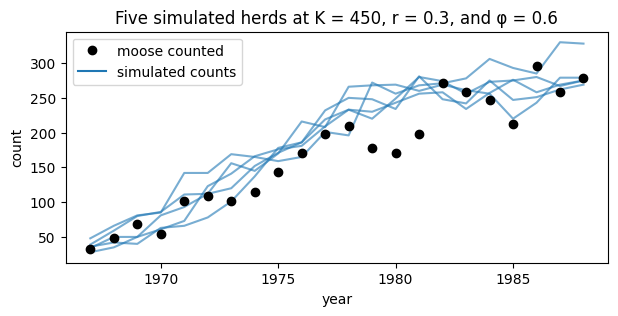

In [6]:
counts_at_values = condition_on(simulator, {"K": 450.0, "r": 0.3, "phi": 0.6})
with workflow_run(seed=1):
    herds = sample(counts_at_values, sample_shape=(5,)).raw()

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(years, herds.T, color="tab:blue", alpha=0.6)
ax.plot(years, counts, "o", color="black", label="moose counted")
ax.plot([], [], color="tab:blue", label="simulated counts")
ax.set(xlabel="year", ylabel="count", title="Five simulated herds at K = 450, r = 0.3, and φ = 0.6")
ax.legend(loc="upper left")
plt.show()

The simulated counts jump from year to year, as the counts do, because each animal's fate is random.
`*` composes the simulator with the prior into the model, as in tutorial 1:

In [7]:
model = (simulator * prior).with_label("model")
print("components of the model:", list(model.event_spec.components))

components of the model: ['y', 'K', 'r', 'phi']


## 3. The same call

`condition_on` conditions the model on the counts, as in tutorial 2.
NUTS follows the gradient of the log density, which this model does not have, and `condition_on.check` reports the method that `condition_on` selects instead:

In [8]:
report = condition_on.check(model, observed)
print("route:", report.route)
print("method:", report.method)
print("exact:", report.exact)

route: inference_methods
method: pyabc_smcabc
exact: False


`pyabc_smcabc` is SMC-ABC from the package pyabc, a method of **approximate Bayesian computation**.
It draws parameters from the prior, simulates counts at each draw, and keeps the draws whose simulations resemble the observed counts.
Two series resemble each other when a few **summaries** of them are close, within a **tolerance**.
Sequential Monte Carlo makes the search efficient: each generation perturbs the draws that the last one kept, and lowers the tolerance.

We summarize a series of counts by four numbers, each computed from the logarithms of the counts:

- the early level: the mean of the first five years;
- the late level: the mean of the last eight years;
- the early growth: the growth rate over the first eight years;
- the jumps: the spread of the changes from year to year.

In [9]:
def summaries(y: jax.Array) -> jax.Array:
    """Four summaries of each row of counts."""
    log_y = jnp.log1p(jnp.atleast_2d(y))
    early_level = log_y[:, :5].mean(axis=-1)
    late_level = log_y[:, -8:].mean(axis=-1)
    early_growth = (log_y[:, 8] - log_y[:, 0]) / 8.0
    jumps = jnp.std(jnp.diff(log_y, axis=-1), axis=-1)
    return jnp.stack([early_level, late_level, early_growth, jumps], axis=-1)


print("summaries of the observed counts:", np.round(np.asarray(summaries(counts))[0], 3))

summaries of the observed counts: [4.061 5.528 0.18  0.209]


The summaries and the budget are settings of the method, which `method_options` sets, as it set the target of TFP's NUTS in tutorial 3.
We run eight generations of 500 draws each, which takes about half a minute:

In [10]:
with workflow_run(seed=2):
    abc_posterior = condition_on.with_options(
        method_options={"summary_fn": summaries, "n_particles": 500, "max_populations": 8}
    )(model, observed)

generations = abc_posterior.annotations["arviz"]["smc_diagnostics"]
print("tolerance of each generation:", np.round(generations["epsilon"].to_numpy(), 3))
print("simulations run:", generations.attrs["total_nr_simulations"])
print("kind of posterior:", type(abc_posterior).__name__)
print("number of weighted draws:", abc_posterior.num_atoms)

tolerance of each generation: [0.734 0.468 0.321 0.236 0.177 0.141 0.117 0.1  ]
simulations run: 22331
kind of posterior: EmpiricalDistribution
number of weighted draws: 500


The tolerance falls with each generation, as the kept draws concentrate on the parameters whose simulations reproduce the summaries.
The posterior is an `EmpiricalDistribution` of weighted draws, like the particles of tutorial 5, so `mean` and `quantile` apply to it as they did to every posterior so far:

In [11]:
parameters = ["K", "r", "phi"]
interval = jnp.array([0.05, 0.95])


def posterior_table(posterior: Distribution) -> pd.DataFrame:
    """The mean and the 90% interval of each parameter."""
    rows = {}
    for name in parameters:
        low, high = np.asarray(quantile(posterior[name], interval).raw())
        rows[name] = {"mean": f"{float(mean(posterior[name])):.3g}", "90% interval": f"({low:.3g}, {high:.3g})"}
    return pd.DataFrame(rows).T


posterior_table(abc_posterior)

,mean,90% interval
K,495,"(376, 668)"
r,0.331,"(0.228, 0.443)"
phi,0.537,"(0.374, 0.71)"


## 4. An amortized posterior

SMC-ABC ran thousands of simulations for these counts, and other counts would need a run of their own.
An **amortized** method spends its simulations once.
It trains a neural network on pairs of parameters and counts, drawn from the prior and the simulator, so that the network returns the posterior given any counts.
`learn_amortized_posterior` trains BayesFlow's neural posterior estimator on 5,000 simulations, which takes about half a minute.
The simulations and the network's starting weights are random, so a seed fixes the trained network.
Its argument `verbose=0` passes to Keras and stops it from printing the progress of each epoch:

In [12]:
with workflow_run(seed=3):
    posterior_given_observation = learn_amortized_posterior(
        prior, simulator, num_simulations=5000, epochs=60, verbose=0
    )
print("given slots of the amortized posterior:", list(posterior_given_observation.given_spec))
print("components of the amortized posterior:", list(posterior_given_observation.event_spec.components))

given slots of the amortized posterior: ['observation']
components of the amortized posterior: ['K', 'r', 'phi']


The amortized posterior is a conditional distribution of the parameters given an observation, which is a series of 22 counts.
`condition_on` evaluates it at the observed counts, as it evaluated the simulator at parameter values in section 2:

In [13]:
with workflow_run(seed=4):
    amortized_posterior = condition_on(posterior_given_observation, {"observation": counts})
metadata = amortized_posterior.provenance.metadata
print("route:", metadata["route"])
print("exact:", metadata["exact"])

route: curry
exact: False


The route `curry` fixes the given values of a conditional distribution, as section 2's call did, and it runs no sampler: each draw of the result is one pass of the network.
The result is approximate, as the network is.
Both posteriors are distributions, so the table of section 3 applies to the amortized one as well.
The amortized posterior's summaries come from draws of the network, so a seed fixes them:

In [14]:
with workflow_run(seed=5):
    amortized_table = posterior_table(amortized_posterior)
amortized_table

,mean,90% interval
K,472,"(355, 593)"
r,0.239,"(0.184, 0.306)"
phi,0.558,"(0.452, 0.693)"


The intervals of $K$ and of $\phi$ from the two posteriors overlap over most of their widths, and the intervals of $r$ differ: SMC-ABC's is wider and higher.
SMC-ABC sees the counts only through four summaries and accepts every simulation within its tolerance, while the network reads the whole series.
Exercise 1 shows how much the posterior of $r$ depends on the summaries, and section 5 checks the amortized posterior.

## 5. Checking the amortized posterior

A network can be wrong, and simulations can test it.
A simulation from the model gives counts whose parameters we know.
If the amortized posterior is calibrated, its 90% intervals hold the known parameters in about 90% of simulations, and its 50% intervals in about half.
Evaluating the network at new counts costs one pass, so a check on 200 simulations takes seconds.
`interval_coverage` reports whether each interval of one posterior holds its parameter:

In [15]:
with workflow_run(seed=6):
    test_draws = sample(model, sample_shape=(200,))
test_counts = test_draws["y"].raw()
test_parameters = np.stack([test_draws[name].raw() for name in parameters], axis=-1)


def posterior_draws(y: jax.Array, num_draws: int = 500) -> np.ndarray:
    """Draws of the parameters from the amortized posterior given counts *y*, one column per parameter."""
    draws = sample(condition_on(posterior_given_observation, {"observation": y}), sample_shape=(num_draws,))
    return np.stack([draws[name].raw() for name in parameters], axis=-1)


with workflow_run(seed=7):
    held = [
        interval_coverage(posterior_draws(y), truth, levels=(0.5, 0.9))
        for y, truth in zip(test_counts, test_parameters)
    ]
for level in (0.5, 0.9):
    shares = np.mean([check[level] for check in held], axis=0)
    listed = ", ".join(f"{name} {share:.2f}" for name, share in zip(parameters, shares))
    print(f"share of the {level:.0%} intervals that hold the parameter: {listed}")

share of the 50% intervals that hold the parameter: K 0.48, r 0.55, phi 0.53
share of the 90% intervals that hold the parameter: K 0.87, r 0.89, phi 0.86


Each share lies within two standard errors of its level, which for 200 simulations are 0.07 at 50% and 0.04 at 90%, so the intervals hold the parameters at their nominal rates.
The same check of SMC-ABC would need 200 runs of section 3.

## Exercises

Each exercise is followed by a solution, which Colab shows collapsed.

**Exercise 1.** SMC-ABC sees the counts only through their summaries.
Fit the model again with the late level as the only summary, and compare the 90% interval of $r$ with section 3's and with the prior's, (0.21, 0.77).

In [16]:
# @title Solution
def late_level(y: jax.Array) -> jax.Array:
    """The late level of each row of counts."""
    return summaries(y)[:, 1:2]


with workflow_run(seed=8):
    late_posterior = condition_on.with_options(
        method_options={"summary_fn": late_level, "n_particles": 500, "max_populations": 8}
    )(model, observed)
for label, posterior in [("four summaries", abc_posterior), ("the late level", late_posterior)]:
    low, high = np.asarray(quantile(posterior["r"], interval).raw())
    print(f"90% interval of r with {label}: ({low:.2f}, {high:.2f})")

90% interval of r with four summaries: (0.23, 0.44)
90% interval of r with the late level: (0.22, 0.79)


**Exercise 2.** Train the amortized posterior on 1,000 simulations instead of 5,000, and check its intervals as in section 5.

In [17]:
# @title Solution
with workflow_run(seed=9):
    small_posterior_given_observation = learn_amortized_posterior(
        prior, simulator, num_simulations=1000, epochs=60, verbose=0
    )


def small_draws(y: jax.Array, num_draws: int = 500) -> np.ndarray:
    draws = sample(condition_on(small_posterior_given_observation, {"observation": y}), sample_shape=(num_draws,))
    return np.stack([draws[name].raw() for name in parameters], axis=-1)


with workflow_run(seed=10):
    small_held = [
        interval_coverage(small_draws(y), truth, levels=(0.9,))
        for y, truth in zip(test_counts, test_parameters)
    ]
shares = np.mean([check[0.9] for check in small_held], axis=0)
listed = ", ".join(f"{name} {share:.2f}" for name, share in zip(parameters, shares))
print(f"share of the 90% intervals that hold the parameter: {listed}")
# A share below 0.86 means intervals that are too narrow, and one above 0.94 intervals that are too wide.

share of the 90% intervals that hold the parameter: K 0.84, r 0.88, phi 0.91


**Exercise 3.** Tutorial 2 found that the counts determine $\phi K$, the count a survey expects at the carrying capacity, more closely than $K$ or $\phi$ alone.
Apply tutorial 2's function `capacity_count` to both posteriors of this tutorial, and compare their 90% intervals with tutorial 2's, (261, 296).

In [18]:
from probpipe import OutputSpec


# @title Solution
from probpipe import function


@function(output_spec=OutputSpec(capacity_count=None))
def capacity_count(K: jax.Array, phi: jax.Array) -> jax.Array:
    return phi * K


with workflow_run(seed=11):
    for label, posterior in [("SMC-ABC", abc_posterior), ("amortized", amortized_posterior)]:
        posterior_capacity_count = capacity_count(posterior["K"], posterior["phi"])
        low, high = np.asarray(quantile(posterior_capacity_count, interval).raw())
        print(
            f"phi * K under the {label} posterior: mean {float(mean(posterior_capacity_count)):.0f}, 90% interval ({low:.0f}, {high:.0f})"
        )

phi * K under the SMC-ABC posterior: mean 259, 90% interval (234, 289)
phi * K under the amortized posterior: mean 260, 90% interval (213, 316)


## Summary

- A simulator is a conditional distribution that draws samples and has no density. Its law is a subclass of `Distribution` that implements only `_sample`, and `conditional_distribution` builds the simulator from a function that returns the law.
- `condition_on` finds that the model can only draw samples, so the call that ran NUTS in tutorial 2 runs SMC-ABC, which needs only simulations.
- `learn_amortized_posterior` trains a network once, and the result is a conditional distribution that `condition_on` evaluates at any counts without running a sampler.
- Simulations with known parameters check the amortized posterior, whose intervals hold the parameters at their nominal rates.

## References

- Cranmer, K., Brehmer, J., and Louppe, G. (2020). The frontier of simulation-based inference. *Proceedings of the National Academy of Sciences*, 117(48), 30055–30062.
- Sisson, S. A., Fan, Y., and Tanaka, M. M. (2007). Sequential Monte Carlo without likelihoods. *Proceedings of the National Academy of Sciences*, 104(6), 1760–1765.
- Klinger, E., Rickert, D., and Hasenauer, J. (2018). pyABC: distributed, likelihood-free inference. *Bioinformatics*, 34(20), 3591–3593.
- Papamakarios, G., and Murray, I. (2016). Fast ε-free inference of simulation models with Bayesian conditional density estimation. *Advances in Neural Information Processing Systems 29*.
- Radev, S. T., Schmitt, M., Schumacher, L., Elsemüller, L., Pratz, V., Schälte, Y., Köthe, U., and Bürkner, P.-C. (2023). BayesFlow: Amortized Bayesian workflows with neural networks. *Journal of Open Source Software*, 8(89), 5702.